In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
import sys

sys.path.insert(0, "../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
f = open(f"data/{NUTS0}_WNV_{NUTS2}_cases_dates.txt", "r")
print(f.read())

months: 6, 7, 8, 9, 10, 
years: 2010, 2011, 2012, 2013, 2018, 2019, 2020, 2021, 


In [4]:
r_u = 0.05
near_u = 0.25
smote = 1
scaler = 'minmax'
#years_to_remove = [year for year in range(2012, 2018)]
years_to_remove = []
path = f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv'

In [5]:
dataset = read_data(path, exclude_years = years_to_remove)
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,8,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,9,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,9,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,12,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,12,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,33,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,13,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,27,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,17,0,0


In [6]:
#Check months

dataset = dataset.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)

In [7]:
dataset

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-06-01,κεντρικης μακεδονιας,αλεξανδρειας,8,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,478.8,38293.0,86.8,46.44911,0.237090,-0.048711,-0.317377,0.048711,0.233606,-0.039714,-0.304677,0.039714,0.064241,0.055555,0.021262,0.055555,27.490000,38.045000,16.935000,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,27.661434,69.883681,634.525996,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407,31,99,36,99.0,30,99,12,12,1,6,7,2,0,60,137,0
1,21.94079,40.97703,2010-06-01,κεντρικης μακεδονιας,αλμωπιας,9,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,985.8,24924.0,28.0,46.48134,0.610494,0.297777,-0.269769,-0.297777,0.589813,0.268988,-0.282681,-0.268988,0.054153,0.046797,0.051947,0.046797,19.087273,24.759091,13.415455,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,19.182475,53.285836,708.081877,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000,14,99,10,99.0,10,99,4,4,6,4,4,2,0,27,71,0
2,22.89198,40.65603,2010-06-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.158598,-0.002042,-0.195420,0.002042,0.161290,-0.000149,-0.195554,0.000149,0.079131,0.039658,0.030081,0.039658,26.500000,35.950000,17.050000,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,60.840037,99.001511,625.519261,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007,32,97,9,99.0,30,97,13,13,10,8,9,2,0,66,65,0
3,23.98253,40.91510,2010-06-01,κεντρικης μακεδονιας,αμφιπολης,33,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,411.8,7169.0,22.3,47.42581,0.600695,0.348246,-0.219345,-0.348246,0.564287,0.283836,-0.257383,-0.283836,0.049732,0.050856,0.027357,0.050856,24.495000,30.690000,18.300000,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,29.119374,48.335329,661.806941,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232,22,74,20,74.0,20,74,9,9,4,1,1,2,0,22,80,0
4,23.69108,40.49593,2010-06-01,κεντρικης μακεδονιας,αριστοτελη,27,1,6,22,2010,0.201299,0.979530,1.224647e-16,-1.0,0.508531,-0.861044,747.0,16994.0,24.5,46.91682,0.517065,0.247244,-0.249138,-0.247244,0.548352,0.286086,-0.228926,-0.286086,0.042899,0.042628,0.027381,0.042628,19.367500,24.000000,14.735000,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,27.828753,56.447650,608.274993,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661,14,99,10,99.0,10,99,4,4,6,4,4,2,0,43,94,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4851,22.14670,40.82294,2021-08-16,κεντρικης μακεδονιας,σκυδρας,7,16,8,33,2021,-0.101168,-0.994869,-8.660254e-01,-0.5,-0.696551,-0.717507,239.5,18080.0,84.3,46.44339,0.445122,0.014416,-0.427180,-0.014416,0.443690,0.017735,-0.421358,-0.017735,0.118285,0.115395,0.067481,0.115395,30.280000,37.640000,22.920000,8.027348,

In [8]:
dataset['lau1'].unique().shape

(38,)

In [9]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2010,291,250,541,11.14%
1,2011,356,31,387,7.97%
2,2012,361,20,381,7.85%
3,2013,363,21,384,7.91%
4,2014,380,0,380,7.83%
5,2015,380,0,380,7.83%
6,2016,380,0,380,7.83%
7,2017,380,0,380,7.83%
8,2018,311,117,428,8.81%
9,2019,344,53,397,8.18%


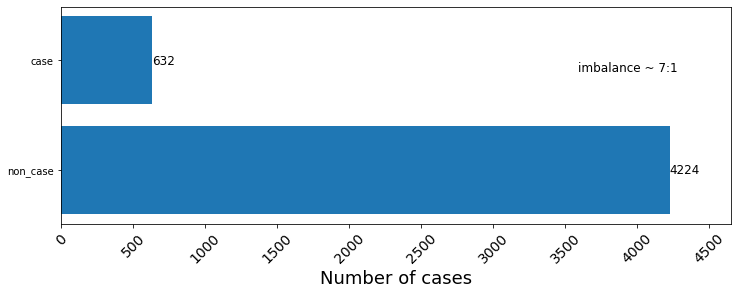

In [10]:
plot_imbalance(dataset)

In [11]:
coefficients = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case']).columns

In [12]:
for train_idx, test_idx in yearCV_split(dataset):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_train = data_train['case']
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = ['case'])
    y_test = data_test['case']
    
    X_train, X_test, y_train, y_test, X_train_df = transform_data(X_train, X_test, y_train, y_test, r_u, near_u, smote, scaler_key=scaler)
    
    w0,w1 = calculate_weights(y_train)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)
    
    train, test, coef = train_and_predict(model, X_train_df, data_test, X_train, y_train, X_test, y_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    coefficients.append(coef)
    
    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

Year: 2010 || w0:1, w1:4 || ##
Year: 2011 || w0:1, w1:3 || ##
Year: 2012 || w0:1, w1:3 || ##
Year: 2013 || w0:1, w1:3 || ##
Year: 2014 || w0:1, w1:3 || ##
Year: 2015 || w0:1, w1:3 || ##
Year: 2016 || w0:1, w1:3 || ##
Year: 2017 || w0:1, w1:3 || ##
Year: 2018 || w0:1, w1:3 || ##
Year: 2019 || w0:1, w1:3 || ##
Year: 2020 || w0:1, w1:3 || ##
Year: 2021 || w0:1, w1:3 || ##


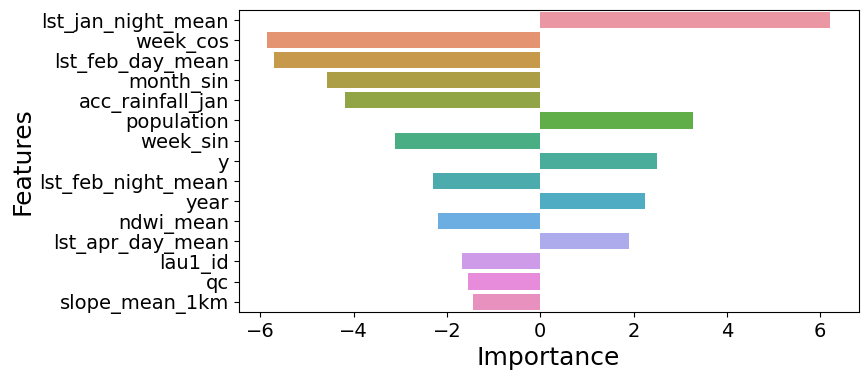

In [13]:
plot_feature_importance(coefficients, feature_names, top = 15, figure_size = (8, 4))

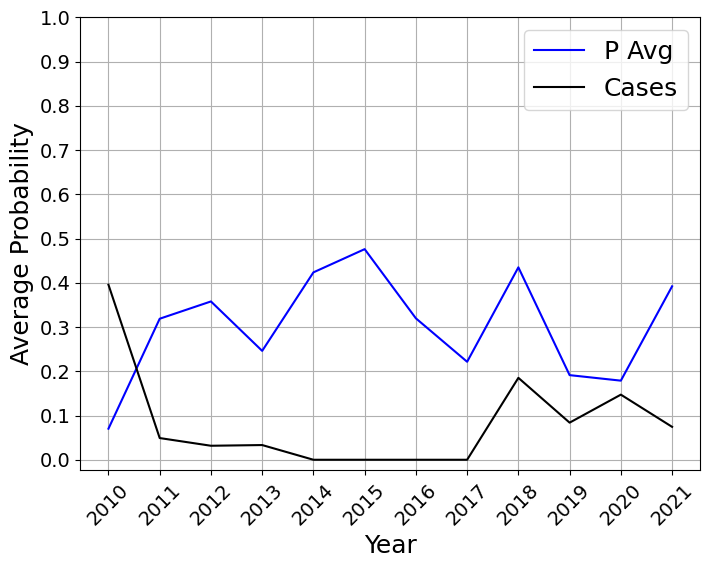

In [14]:
plot_trend_curve(results_test, list(dsc['case']))

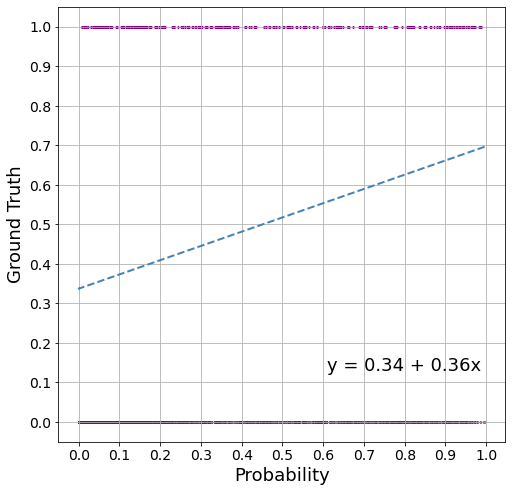

In [15]:
plot_probability_curve(results_test)

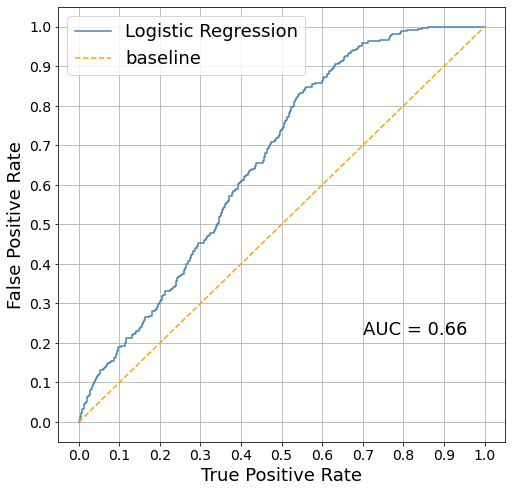

In [16]:
plot_roc_curve(results_test)

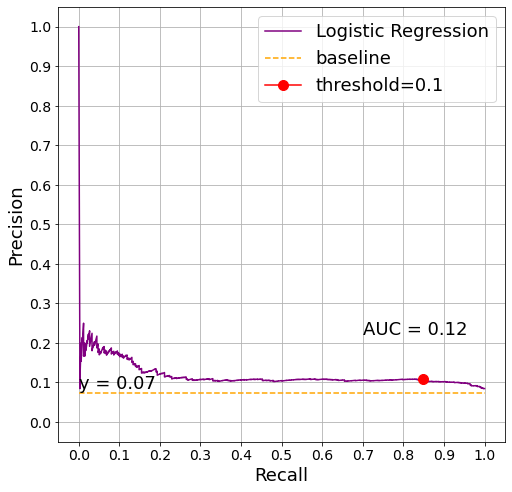

In [17]:
plot_pr_curve(results_test, plot_fbeta=True)

In [18]:
operational, cumulative, avg, weighted = evaluate_operational(results_test, k = 5, prob_threshold = -1)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')

Average: 34.38%
Weighted Average: 43.42%


In [19]:
operational

,Prediction Date,Infected,Discovered,Out of,Percentage,percentage
0,01/06/2010,0,0,0,NaN,NaN
1,16/06/2010,0,0,0,NaN,NaN
2,01/07/2010,1,0,1,0.00 %,0.00
3,16/07/2010,12,5,5,100.00 %,1.00
4,01/08/2010,23,5,5,100.00 %,1.00
...,...,...,...,...,...,...
115,16/08/2021,8,2,5,40.00 %,0.40
116,01/09/2021,4,1,4,25.00 %,0.25
117,16/09/2021,1,1,1,100.00 %,1.00
118,01/10/2021,1,0,1,0.00 %,0.00


In [20]:
cumulative

,Year,Infected,Discovered,Out Of,Percentage,percentage
0,2010,89,20,26,76.92 %,0.7692
1,2011,24,8,20,40.00 %,0.4000
2,2012,19,3,19,15.79 %,0.1579
3,2013,17,1,17,5.88 %,0.0588
4,2014,0,0,0,nan %,NaN
5,2015,0,0,0,nan %,NaN
6,2016,0,0,0,nan %,NaN
7,2017,0,0,0,nan %,NaN
8,2018,69,14,34,41.18 %,0.4118
9,2019,36,5,24,20.83 %,0.2083


In [21]:
report_train, report_test = classification_report(results_train, results_test, threshold = 0.1, beta = 4)

In [22]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2010,89.0,0.2474,0.7787,0.6383,0.6742,0.6719,0.5325
1,2011,24.0,0.6211,0.7022,0.1017,1.0000,0.6581,0.4903
2,2012,19.0,0.6184,0.6454,0.0723,0.8947,0.5362,0.7437
3,2013,17.0,0.5579,0.7006,0.0755,0.9412,0.5620,0.3775
4,2014,0.0,0.7184,0.2816,0.0000,0.0000,0.0000,0.8220
5,2015,0.0,0.7342,0.2658,0.0000,0.0000,0.0000,1.0479
6,2016,0.0,0.6211,0.3789,0.0000,0.0000,0.0000,0.5319
7,2017,0.0,0.5342,0.4658,0.0000,0.0000,0.0000,0.3315
8,2018,69.0,0.7447,0.6471,0.2403,0.9855,0.8335,0.7063
9,2019,36.0,0.4737,0.7293,0.1778,0.8889,0.7196,0.3550


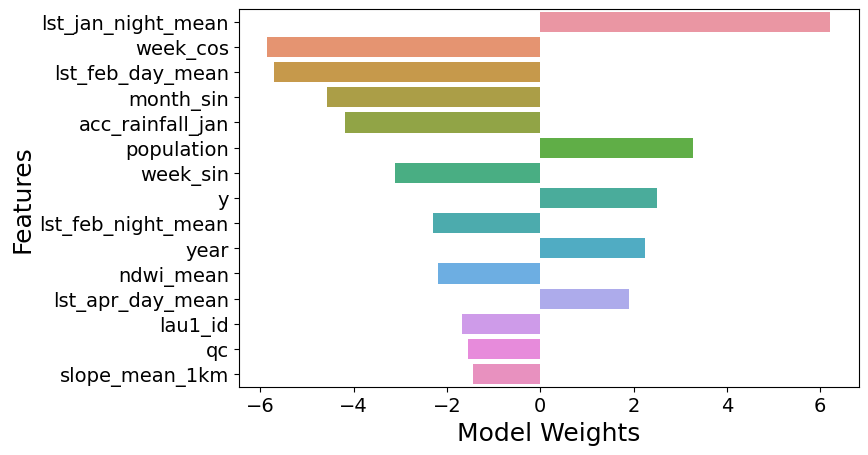

In [23]:
plot_feature_importance(coefficients, feature_names,  x_label = 'Model Weights', top = 15, figure_size = (8, 5))